# **Dataset**

# **importing libraries**

In [40]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns



# **Loading Data**

In [41]:
mdf = pd.read_csv(r"/content/titanic_train.csv")
mdf = mdf.drop(['PassengerId'] , axis = 1)

In [42]:
mdf.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Data Information**

In [43]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [44]:
mdf.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

# **Data Visualization**

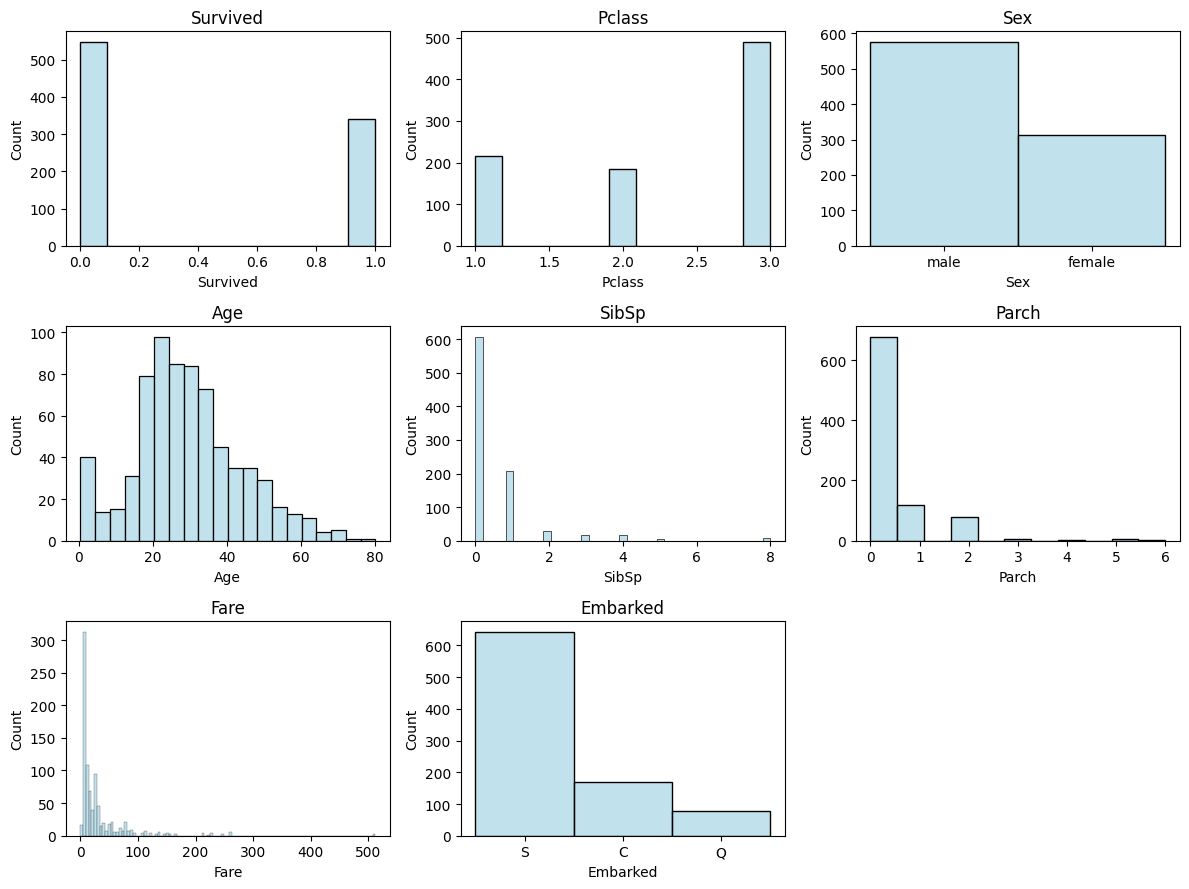

In [45]:
visual_data = mdf.drop(['Ticket' ,'Name'  , 'Cabin'] , axis = 1)

num_cols = len(visual_data.columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(12, 3 * num_rows))
axes = axes.flatten()

for i, column in enumerate(visual_data.columns):
    ax = axes[i]
    sns.histplot(visual_data[column], ax=ax, color = "lightblue")
    ax.set_title(column)

for i in range(num_cols, num_rows * 3):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# **Data Preprocessing**

# Clean up and Removing useless features

In [46]:
mdf = mdf.drop(['Name' ,'Ticket'] , axis = 1)
mdf.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# Missing values

In [47]:
mdf = mdf.drop(['Cabin'] , axis = 1)

imp = SimpleImputer(strategy = 'mean')
mdf[['Age', 'Fare']] = imp.fit_transform(mdf[['Age', 'Fare']])
mdf[['Age', 'Fare']] = pd.DataFrame(mdf[['Age', 'Fare']] , columns = ['Age' , 'Fare'])

In [48]:
imp = SimpleImputer(strategy = 'most_frequent')
mdf[['Embarked']] = imp.fit_transform(mdf[['Embarked']])
mdf[['Embarked']] = pd.DataFrame(mdf[['Embarked']] , columns = ['Embarked'])


In [49]:
mdf.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [50]:
mdf.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

#  Categorical data

In [51]:
nominals = ['Sex' , 'Embarked' ,"Ticket_item"]
ordinals = ['Pclass' , "Parch" , "SibSp"]


le = LabelEncoder()
mdf['Sex'] = le.fit_transform(mdf['Sex'])
mdf['Embarked'] = le.fit_transform(mdf['Embarked'])


mdf.head(7)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,2
1,1,1,0,38.000000,1,0,71.2833,0
2,1,3,0,26.000000,0,0,7.9250,2
3,1,1,0,35.000000,1,0,53.1000,2
4,0,3,1,35.000000,0,0,8.0500,2
5,0,3,1,29.699118,0,0,8.4583,1
6,0,1,1,54.000000,0,0,51.8625,2


In [52]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


# Outliers

In [53]:
mdf.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,1.536476
std,0.486592,0.836071,0.477990,13.002015,1.102743,0.806057,49.693429,0.791503
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,1.000000,29.699118,0.000000,0.000000,14.454200,2.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


In [54]:
threshold = 2.5

z_scores = np.abs((mdf -mdf.mean()) / mdf.std())

outliers = z_scores > threshold

outliers.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


In [55]:
z_scores = np.abs((mdf - mdf.mean()) / mdf.std())

mdf = mdf[(z_scores <= threshold)]

mdf.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1.0,0.0,7.2500,2
1,1,1,0,38.0,1.0,0.0,71.2833,0
2,1,3,0,26.0,0.0,0.0,7.9250,2
3,1,1,0,35.0,1.0,0.0,53.1000,2
4,0,3,1,35.0,0.0,0.0,8.0500,2


In [56]:
mdf.isnull().sum()

Survived     0
Pclass       0
Sex          0
Age         15
SibSp       30
Parch       15
Fare        22
Embarked     0
dtype: int64

In [57]:
mdf =mdf.dropna()

mdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 811 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  811 non-null    int64  
 1   Pclass    811 non-null    int64  
 2   Sex       811 non-null    int64  
 3   Age       811 non-null    float64
 4   SibSp     811 non-null    float64
 5   Parch     811 non-null    float64
 6   Fare      811 non-null    float64
 7   Embarked  811 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 57.0 KB


# Splitting to test , validation set

In [58]:
X = mdf.drop('Survived' , axis =1)
y= mdf['Survived']


X_train ,X_test ,y_train ,y_test = train_test_split( X , y , test_size = 0.3 ,random_state =42)

print(X.shape)
print(y.shape)

print(X_test.shape)
print( y_test.shape)

(811, 7)
(811,)
(244, 7)
(244,)


#  Data transformation

In [59]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train) , columns = X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test) , columns = X_test.columns)

In [60]:
X_train.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.823735,0.712726,-0.617349,-0.562351,-0.436341,-0.616162,0.572160
1,-0.405364,0.712726,0.596845,-0.562351,3.256275,0.028433,0.572160
2,-1.634464,0.712726,2.732151,-0.562351,-0.436341,0.047618,0.572160
3,0.823735,0.712726,-0.491743,-0.562351,-0.436341,-0.626334,-1.972270
4,0.823735,-1.403063,-0.952299,-0.562351,-0.436341,-0.535204,0.572160
5,0.823735,0.712726,-0.533612,-0.562351,-0.436341,-0.604533,0.572160
6,-0.405364,-1.403063,0.554976,1.064450,-0.436341,0.028433,0.572160
7,0.823735,0.712726,0.027356,1.064450,-0.436341,-0.337830,-0.700055
8,0.823735,0.712726,0.303763,1.064450,1.409967,-0.162547,0.572160
9,-1.634464,0.712726,2.062251,-0.562351,1.409967,1.817453,0.572160


#  Correlation

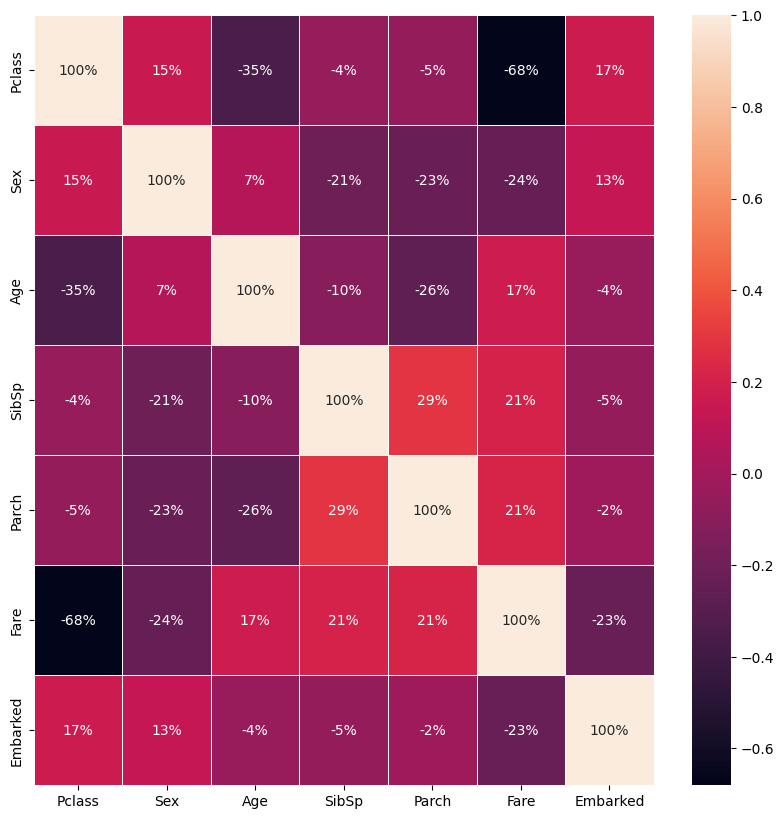

In [61]:
f,ax=plt.subplots(figsize=(10,10))
sns.heatmap(X_train.corr(),annot=True,linewidths=.5,fmt='.0%',ax=ax)
plt.show()

In [62]:
knn=KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4)

In [63]:
print(classification_report(y_test,knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.77      0.93      0.85       147
           1       0.85      0.59      0.70        97

    accuracy                           0.80       244
   macro avg       0.81      0.76      0.77       244
weighted avg       0.80      0.80      0.79       244



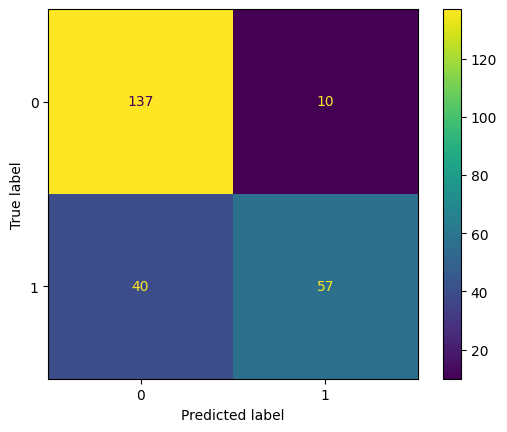

In [64]:
predictions=knn.predict(X_test)
confm=confusion_matrix(y_test,predictions , labels=knn.classes_)
pr=ConfusionMatrixDisplay(confusion_matrix=confm,display_labels=knn.classes_)
pr.plot()

In [65]:
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=6)

In [66]:
print(classification_report(y_test,knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.79      0.93      0.86       147
           1       0.86      0.63      0.73        97

    accuracy                           0.81       244
   macro avg       0.83      0.78      0.79       244
weighted avg       0.82      0.81      0.80       244



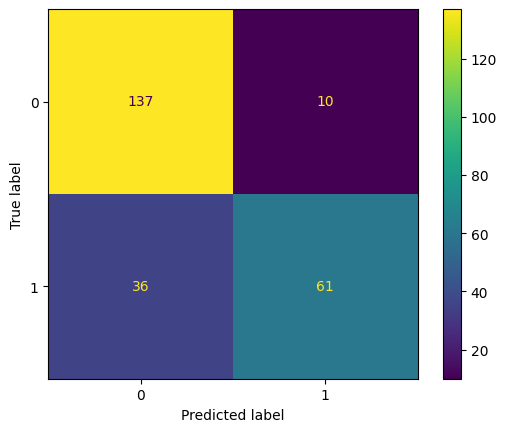

In [67]:
predictions=knn.predict(X_test)
confm=confusion_matrix(y_test,predictions , labels=knn.classes_)
pr=ConfusionMatrixDisplay(confusion_matrix=confm,display_labels=knn.classes_)
pr.plot()

In [68]:
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [69]:
print(classification_report(y_test,knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       147
           1       0.80      0.73      0.76        97

    accuracy                           0.82       244
   macro avg       0.82      0.80      0.81       244
weighted avg       0.82      0.82      0.82       244



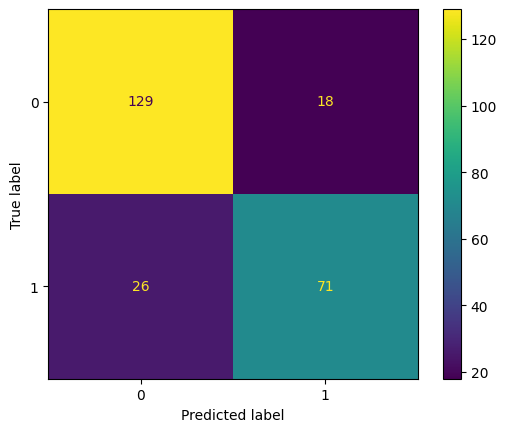

In [70]:
predictions=knn.predict(X_test)
confm=confusion_matrix(y_test,predictions , labels=knn.classes_)
pr=ConfusionMatrixDisplay(confusion_matrix=confm,display_labels=knn.classes_)
pr.plot()

In [71]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [72]:
print(classification_report(y_test,knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       147
           1       0.78      0.65      0.71        97

    accuracy                           0.79       244
   macro avg       0.78      0.76      0.77       244
weighted avg       0.79      0.79      0.78       244



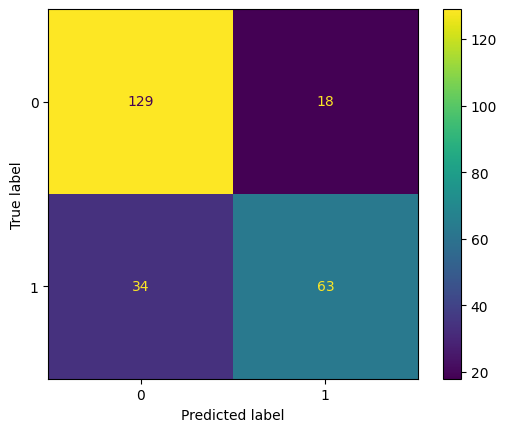

In [73]:
predictions=knn.predict(X_test)
confm=confusion_matrix(y_test,predictions , labels=knn.classes_)
pr=ConfusionMatrixDisplay(confusion_matrix=confm,display_labels=knn.classes_)
pr.plot()